In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,2a3e9_00000,0,339.397816,bald,1,13945.161980
1,1,2a3e9_00000,1,357.577855,bald,1,13945.161980
2,2,2a3e9_00000,2,363.612961,bald,1,13945.161980
3,3,2a3e9_00000,3,359.578236,bald,1,13945.161980
4,4,2a3e9_00000,4,347.404700,bald,1,13945.161980
...,...,...,...,...,...,...,...
6295,6295,2a3e9_00034,175,1.056353,random,5,54940.314679
6296,6296,2a3e9_00034,176,0.975662,random,5,54940.314679
6297,6297,2a3e9_00034,177,0.948536,random,5,54940.314679
6298,6298,2a3e9_00034,178,0.958707,random,5,54940.314679


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
5400,5400,2a3e9_00030,0,339.397816,random,1,47537.534558
5401,5401,2a3e9_00030,1,334.684824,random,1,47537.534558
5402,5402,2a3e9_00030,2,413.413116,random,1,47537.534558
5403,5403,2a3e9_00030,3,403.202578,random,1,47537.534558
5404,5404,2a3e9_00030,4,405.703529,random,1,47537.534558
...,...,...,...,...,...,...,...
6295,6295,2a3e9_00034,175,1.056353,random,5,54940.314679
6296,6296,2a3e9_00034,176,0.975662,random,5,54940.314679
6297,6297,2a3e9_00034,177,0.948536,random,5,54940.314679
6298,6298,2a3e9_00034,178,0.958707,random,5,54940.314679


In [4]:
def format_scientific_tight(value):
    """
    Formats a number using scientific notation without the + sign.
    """
    return f"{value:.2e}".replace('e+0', 'e').replace('e+', 'e')

In [5]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{format_scientific_tight(row.avg)} ± {format_scientific_tight(row.stdv)}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_36225/3633301443.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


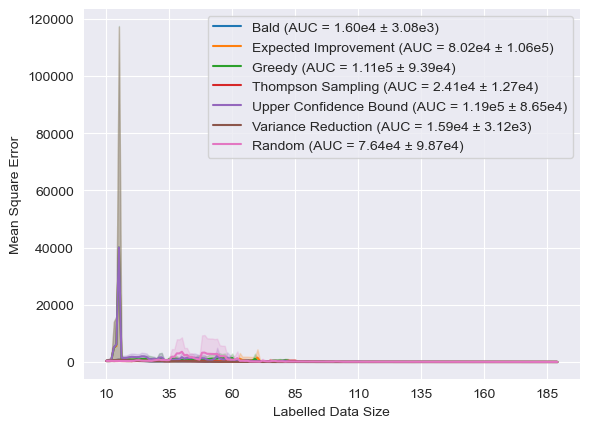

In [6]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")


current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
legend.set_title(None) 
    

for spine in ax.spines.values():
    spine.set_visible(False)